In [2]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06
opto_thresh = 1.8
control_thresh = 3.5

TARGET_COLOR = '#ff3654'
NONTARGET_COLOR = '#5776ff'
CR_COLOR = '#808080'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']

In [3]:
post_opto = ['BS_86','BS_119','BS_123','BS_128','BS_131','BS_163','BS_174']
post_control =  ['AE_287']

all_animals = np.concatenate([post_opto, post_control])

In [4]:
df = pd.read_csv('../../Source Data Files/Figure 3c.csv')

In [5]:
df

,Unnamed: 0,animal,session,cluster ID,category,condition,FRmod laser off,percent change in FRmod laser on
0,0,BS_119,BS_119_2_opto_AC.pickle,12,CR,opto,1.904762,9.191176
1,1,BS_119,BS_119_2_opto_AC.pickle,16,CR,opto,6.203305,6.637424
2,2,BS_119,BS_119_2_opto_AC.pickle,22,CR,opto,2.895115,-19.378994
3,3,BS_119,BS_119_2_opto_AC.pickle,50,CR,opto,2.589799,9.773790
4,4,BS_119,BS_119_2_opto_AC.pickle,53,CR,opto,2.927443,-8.807210
...,...,...,...,...,...,...,...,...
805,805,AE_287,AE_287_9_opto_control_AC.pickle,123,NCR,control,3.031798,13.381555
806,806,AE_287,AE_287_9_opto_control_AC.pickle,125,NCR,control,0.697740,59.516943
807,807,AE_287,AE_287_9_opto_control_AC.pickle,137,NCR,control,0.625000,-40.540541
808,808,AE_287,AE_287_9_opto_control_AC.pickle,140,NCR,control,0.792484,104.594352


In [6]:
FRmod_off = []
FRmod_delta_pc = []
for row in df.iloc():
    if row['condition'] == 'opto':
        FRmod_off.append(row['FRmod laser off'])
        FRmod_delta_pc.append(row['percent change in FRmod laser on'])
FRmod_off = np.array(FRmod_off)
FRmod_delta_pc = np.array(FRmod_delta_pc)

In [7]:
opto_df = df[df['condition']=='opto']
print(np.sum(opto_df['category']=='CR'))
print(np.sum(opto_df['category']=='NCR'))

295
227


CR
17.66212961072393
NCR
132.28702017466796


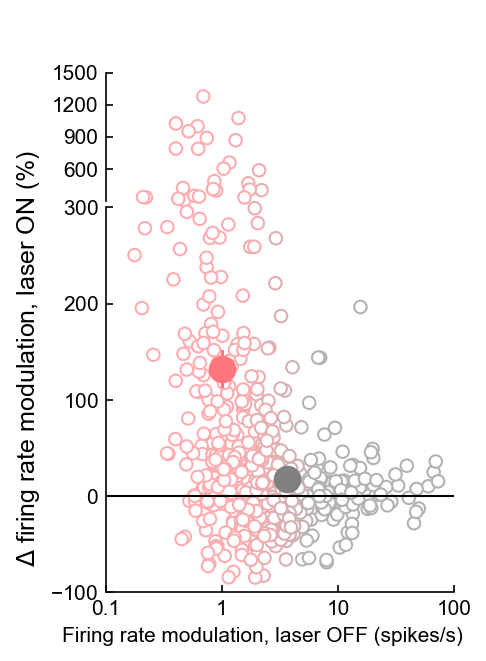

In [8]:
X = 3.25
Y = 4
X = X + 0.3
Y = Y + 0.3

fig = plt.figure(figsize=(3,4.5))
gs = fig.add_gridspec(2,1,height_ratios=[1,3],hspace=0.025)
class Baxes:
    axs: np.ndarray = np.array([None,None],dtype=object)
bax = Baxes()

bax.axs[0] = plt.subplot(gs[0,0])
bax.axs[1] = plt.subplot(gs[1,0])

bax.axs[1].set_xscale('log',subs=[])
bax.axs[1].set_xlim([0.1,100])
bax.axs[1].set_xticks([0.1,1,10,100])
bax.axs[1].set_xticklabels(['0.1','1','10','100'])
bax.axs[1].set_ylim([-100,300])
bax.axs[1].set_yticks([-100,0,100,200,300])

bax.axs[0].set_xscale('log',subs=[])
bax.axs[0].set_xlim([0.1,100])
bax.axs[0].xaxis.set_visible(False)
bax.axs[0].spines['bottom'].set_visible(False)
bax.axs[0].set_ylim([300,1500])
bax.axs[0].set_yticks([600,900,1200,1500])
bax.axs[0].set_yticklabels(['600','900','1200','1500'])

CR_NCR_median = 1.8
colors = NCR_CR_cmap((np.array(FRmod_off)-1)/5)
bax.axs[0].scatter(FRmod_off[np.greater_equal(FRmod_delta_pc,300)],FRmod_delta_pc[np.greater_equal(FRmod_delta_pc,300)],fc='white',ec=colors[np.greater_equal(FRmod_delta_pc,300)],zorder=-10,clip_on=False)
bax.axs[1].scatter(FRmod_off[np.less(FRmod_delta_pc,300)],FRmod_delta_pc[np.less(FRmod_delta_pc,300)],fc='white',ec=colors[np.less(FRmod_delta_pc,300)],zorder=-10,clip_on=False)

mask_CR = np.greater_equal(FRmod_off,CR_NCR_median)
mask_NCR = np.less(FRmod_off,CR_NCR_median)
median_FRmod_off_CR = np.median(FRmod_off[mask_CR])
median_FRmod_off_NCR = np.median(FRmod_off[mask_NCR])
median_FRmod_delta_pc_CR = np.median(FRmod_delta_pc[mask_CR])
median_FRmod_delta_pc_NCR = np.median(FRmod_delta_pc[mask_NCR])
sem_FRmod_delta_pc_CR = sem(FRmod_delta_pc[mask_CR])
sem_FRmod_delta_pc_NCR = sem(FRmod_delta_pc[mask_NCR])

median_value = np.mean(FRmod_delta_pc[mask_CR])
print('CR')
print(median_value)
Q1 = median_value - sem(FRmod_delta_pc[mask_CR])
Q3 = median_value + sem(FRmod_delta_pc[mask_CR])
bax.axs[1].scatter([median_FRmod_off_CR],[median_value],s=150,color=CR_COLOR,zorder=20,clip_on=False)
bax.axs[1].plot([median_FRmod_off_CR]*2,[Q1,Q3],zorder=21,color=CR_COLOR,clip_on=False)

median_value = np.mean(FRmod_delta_pc[mask_NCR])
print('NCR')
print(median_value)
Q1 = median_value - sem(FRmod_delta_pc[mask_NCR])
Q3 = median_value + sem(FRmod_delta_pc[mask_NCR])
bax.axs[1].scatter([median_FRmod_off_NCR],[median_value],s=150,color=NCR_COLOR,zorder=20,clip_on=False)
bax.axs[1].plot([median_FRmod_off_NCR]*2,[Q1,Q3],zorder=21,color=NCR_COLOR,clip_on=False)

bax.axs[1].set_xlabel('Firing rate modulation, laser OFF (spikes/s)      ',fontsize=10)
bax.axs[1].set_ylabel(r'            $\Delta$ firing rate modulation, laser ON (%)',fontsize=12)

bax.axs[1].axhline(0,linestyle='-',color='k',zorder=10,lw=1)
bax.axs[1].fill_between([0.15,100],[-120,-120],[500,500],fc='white',lw=0,alpha=0.4,zorder=-5,clip_on=False)

# fig.savefig(os.path.join('..','..','Figures','Figure 3c.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')

In [9]:
mannwhitneyu(FRmod_delta_pc[mask_NCR],FRmod_delta_pc[mask_CR])

MannwhitneyuResult(statistic=np.float64(46466.0), pvalue=np.float64(2.9704083962369005e-14))